In [111]:
import numpy as np
import pandas as pd

def generar_datos(n=100,
                  f_tiempos=(1.0, 0.8),                      # ("Inicio", "Final")
                  f_entrenamientos=(1.0, 1.1, 1.2, 1.1, 0.9),# (1..5) multipliers
                  f_posiciones=(1.0, 1.3),                   # ("Laterales", "Central")
                  # --- Interacción sobreentrenamiento × alimentación ---
                  umbral_sobre=4,                            # sesiones desde donde hay sobreentrenamiento
                  niveles_alimentacion=("Normal", "Buena"),
                  inter_sobre_entrenamiento=(0.90, 1.00),    # (Normal, Buena): 0.90 reduce 10%, 1.00 no afecta
                  semilla=4):
    """
    Genera datos aleatorios con efectos multiplicativos sobre 'tiempo_salto' (p.ej. milisegundos).
    Incluye interacción entre sobreentrenamiento y alimentación.

    Parámetros:
    - n: número de observaciones
    - f_tiempos: multiplicadores para ("Inicio", "Final")
    - f_entrenamientos: multiplicadores para niveles de entrenamiento (1..5)
    - f_posiciones: multiplicadores para ("Laterales", "Central")
    - umbral_sobre: a partir de cuántas sesiones se considera sobreentrenamiento
    - niveles_alimentacion: ("Normal", "Buena")
    - inter_sobre_entrenamiento: multiplicadores extra cuando hay sobreentrenamiento
        * índice 0 -> alimentación "Normal"
        * índice 1 -> alimentación "Buena"
    - semilla: semilla aleatoria
    """
    rng = np.random.default_rng(semilla)

    # Definición de factores
    tiempos = ["Inicio", "Final"]
    entrenamientos = [1, 2, 3, 4, 5]
    posiciones = ["Laterales", "Central"]
    alimentaciones = list(niveles_alimentacion)

    # Mapas de efectos principales
    map_tiempo = dict(zip(tiempos, f_tiempos))
    map_entren = dict(zip(entrenamientos, f_entrenamientos))
    map_pos    = dict(zip(posiciones, f_posiciones))
    map_inter  = dict(zip(alimentaciones, inter_sobre_entrenamiento))

    # Generar combinaciones aleatorias
    data = {
        "tiempo": rng.choice(tiempos, n),
        "entrenamiento": rng.choice(entrenamientos, n),
        "posicion": rng.choice(posiciones, n),
        "alimentacion": rng.choice(alimentaciones, n),
    }

    # Variable dependiente base (p.ej., 1000 ms ± 100)
    tiempo_salto = rng.normal(loc=1000.0, scale=50.0, size=n)

    # Aplicar efectos principales (multiplicativos)
    for i in range(n):
        t  = data["tiempo"][i]
        e  = data["entrenamiento"][i]
        p  = data["posicion"][i]
        a  = data["alimentacion"][i]

        tiempo_salto[i] *= map_tiempo[t]
        tiempo_salto[i] *= map_entren[e]
        tiempo_salto[i] *= map_pos[p]

        # --- Interacción: sobreentrenamiento × alimentación ---
        # Si entrenamiento >= umbral y alimentación es "Normal" => aplicar penalización (reduce tiempo)
        # Si alimentación es "Buena" => no afecta (multiplicador 1.0 por defecto)
        if e >= umbral_sobre:
            tiempo_salto[i] *= map_inter[a]

    # DataFrame final
    df = pd.DataFrame(data)
    df["tiempo_salto"] = tiempo_salto

    return df

# Ejemplo de uso
if __name__ == "__main__":
    df = generar_datos(
        n=200,
        f_tiempos=(1.0, 0.8),                  # Final reduce 20%
        f_entrenamientos=(1.0, 1.1, 1.2, 1.3, 1.3),
        f_posiciones=(1.0, 1.3),
        umbral_sobre=4,
        niveles_alimentacion=("Normal", "Buena"),
        inter_sobre_entrenamiento=(0.80, 1.00),# Normal: -10%; Buena: sin efecto
        semilla=4
    )
    print(df.head(10))


   tiempo  entrenamiento   posicion alimentacion  tiempo_salto
0   Final              4  Laterales        Buena      1012.683
1   Final              1    Central       Normal      1048.669
2   Final              4    Central        Buena      1330.642
3   Final              1    Central        Buena      1057.107
4   Final              3    Central        Buena      1246.453
5   Final              4    Central        Buena      1299.018
6   Final              1  Laterales       Normal       700.095
7  Inicio              2  Laterales       Normal      1038.687
8  Inicio              4  Laterales       Normal      1121.094
9   Final              4    Central        Buena      1393.121


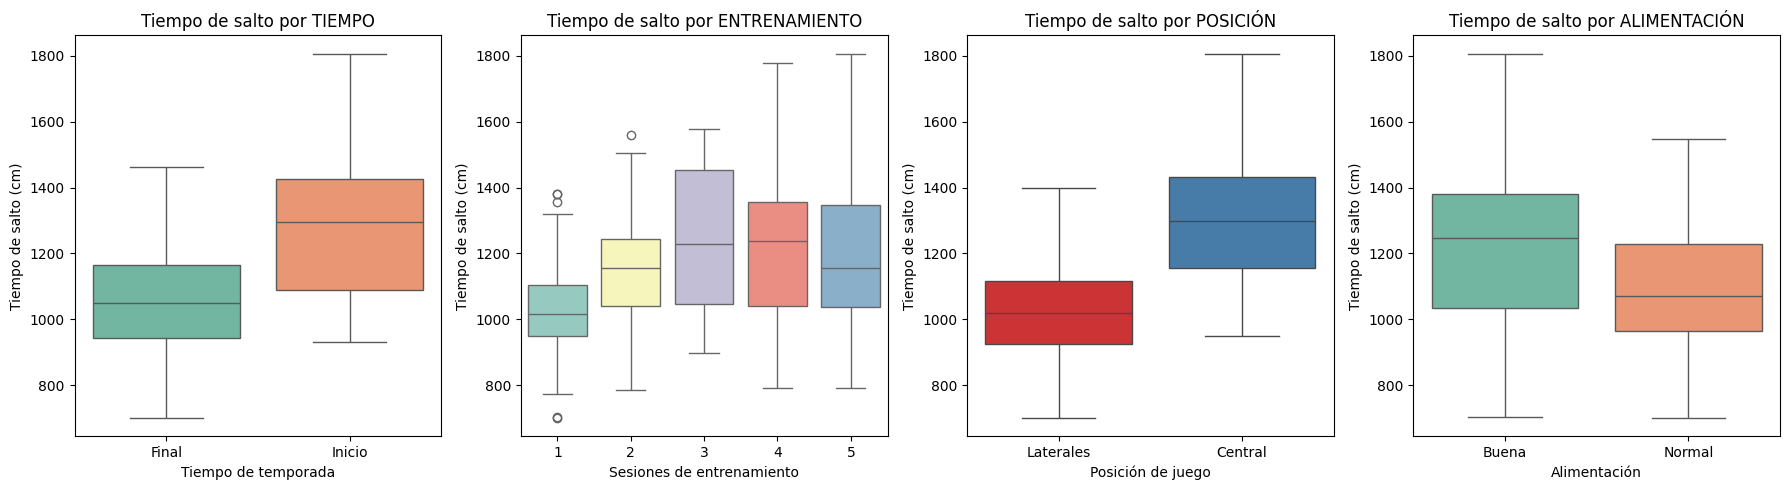

In [112]:
import seaborn as sns
import matplotlib.pyplot as plt
def graficas_por_nivel(df):
    fig, axes = plt.subplots(1, 4, figsize=(18, 5))

    # Tiempo
    sns.boxplot(x="tiempo", y="tiempo_salto", hue="tiempo",
                data=df, ax=axes[0], palette="Set2", legend=False)
    axes[0].set_title("Tiempo de salto por TIEMPO")
    axes[0].set_ylabel("Tiempo de salto (cm)")
    axes[0].set_xlabel("Tiempo de temporada")

    # Entrenamiento
    sns.boxplot(x="entrenamiento", y="tiempo_salto", hue="entrenamiento",
                data=df, ax=axes[1], palette="Set3", legend=False)
    axes[1].set_title("Tiempo de salto por ENTRENAMIENTO")
    axes[1].set_ylabel("Tiempo de salto (cm)")
    axes[1].set_xlabel("Sesiones de entrenamiento")

    # Posición
    sns.boxplot(x="posicion", y="tiempo_salto", hue="posicion",
                data=df, ax=axes[2], palette="Set1", legend=False)
    axes[2].set_title("Tiempo de salto por POSICIÓN")
    axes[2].set_ylabel("Tiempo de salto (cm)")
    axes[2].set_xlabel("Posición de juego")
    
        # Tiempo
    sns.boxplot(x="alimentacion", y="tiempo_salto", hue="alimentacion",
    data=df, ax=axes[3], palette="Set2", legend=False)
    axes[3].set_title("Tiempo de salto por ALIMENTACIÓN")
    axes[3].set_ylabel("Tiempo de salto (cm)")
    axes[3].set_xlabel("Alimentación")

    plt.tight_layout()
    plt.show()

graficas_por_nivel(df)

In [125]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
import pandas as pd

# Ajuste del modelo con interacción
modelo = ols(
    'tiempo_salto ~ C(tiempo) + C(posicion) + C(entrenamiento) '
    '+ C(alimentacion) + C(alimentacion)*C(entrenamiento)', 
    data=df
).fit()

# ANOVA
anova_tabla = sm.stats.anova_lm(modelo, typ=2)

# Calcular % de varianza explicada
suma_total = anova_tabla["sum_sq"].sum()
anova_tabla["var_exp_%"] = 100 * anova_tabla["sum_sq"] / suma_total

# Formato bonito
pd.set_option("display.float_format", "{:.3f}".format)
print(anova_tabla)


                                      sum_sq      df        F  PR(>F)  \
C(tiempo)                        3473276.987   1.000  850.567   0.000   
C(posicion)                      4740462.508   1.000 1160.887   0.000   
C(entrenamiento)                 1051670.159   4.000   64.386   0.000   
C(alimentacion)                   804407.015   1.000  196.990   0.000   
C(alimentacion):C(entrenamiento)  913925.863   4.000   55.953   0.000   
Residual                          767694.780 188.000      NaN     NaN   

                                  var_exp_%  
C(tiempo)                            29.556  
C(posicion)                          40.339  
C(entrenamiento)                      8.949  
C(alimentacion)                       6.845  
C(alimentacion):C(entrenamiento)      7.777  
Residual                              6.533  


  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj    lower    upper   reject
-------------------------------------------------------
     1      2 114.2832 0.1624  -24.9206  253.487  False
     1      3 197.1332 0.0061   39.7955 354.4709   True
     1      4 191.0652 0.0007   61.1382 320.9922   True
     1      5 183.7215 0.0038   42.8112 324.6317   True
     2      3    82.85 0.5819  -72.1316 237.8316  False
     2      4   76.782 0.4588  -50.2816 203.8456  False
     2      5  69.4382 0.6395  -68.8362 207.7127  False
     3      4   -6.068    1.0 -152.7739 140.6378  False
     3      5 -13.4118 0.9993 -169.9279 143.1043  False
     4      5  -7.3437 0.9999 -136.2746 121.5871  False
-------------------------------------------------------


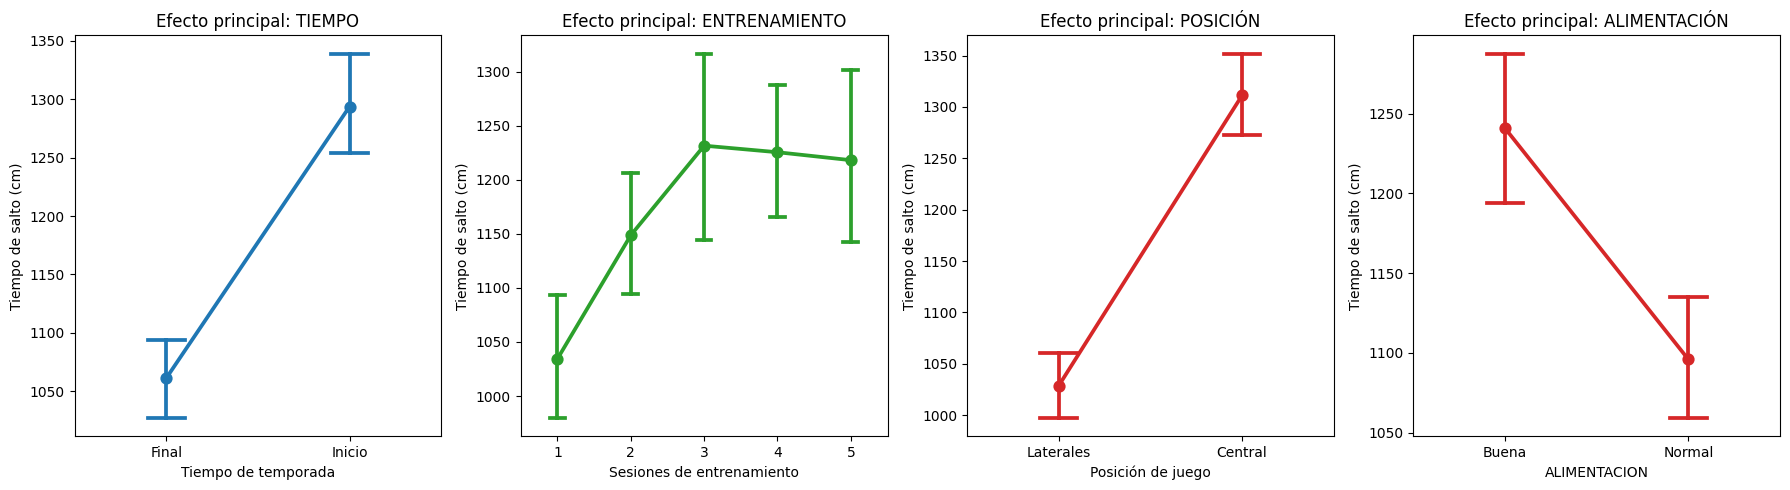

In [116]:

import seaborn as sns
import matplotlib.pyplot as plt

def graficas_efectos_principales(df,ci = 95):
    fig, axes = plt.subplots(1, 4, figsize=(18, 5))

    # --- Efecto principal: Tiempo ---
    sns.pointplot(x="tiempo", y="tiempo_salto", data=df, 
                  ax=axes[0], capsize=0.2, errorbar=('ci', ci), color="tab:blue")
    axes[0].set_title("Efecto principal: TIEMPO")
    axes[0].set_ylabel("Tiempo de salto (cm)")
    axes[0].set_xlabel("Tiempo de temporada")

    # --- Efecto principal: Entrenamiento ---
    sns.pointplot(x="entrenamiento", y="tiempo_salto", data=df, 
                  ax=axes[1], capsize=0.2, errorbar=('ci', ci), color="tab:green")
    axes[1].set_title("Efecto principal: ENTRENAMIENTO")
    axes[1].set_ylabel("Tiempo de salto (cm)")
    axes[1].set_xlabel("Sesiones de entrenamiento")

    # --- Efecto principal: Posición ---
    sns.pointplot(x="posicion", y="tiempo_salto", data=df, 
                  ax=axes[2], capsize=0.2, errorbar=('ci', ci), color="tab:red")
    axes[2].set_title("Efecto principal: POSICIÓN")
    axes[2].set_ylabel("Tiempo de salto (cm)")
    axes[2].set_xlabel("Posición de juego")
    
    sns.pointplot(x="alimentacion", y="tiempo_salto", data=df, 
                  ax=axes[3], capsize=0.2, errorbar=('ci', ci), color="tab:red")
    axes[3].set_title("Efecto principal: ALIMENTACIÓN")
    axes[3].set_ylabel("Tiempo de salto (cm)")
    axes[3].set_xlabel("ALIMENTACION")

    plt.tight_layout()
    plt.show()
graficas_efectos_principales(df)

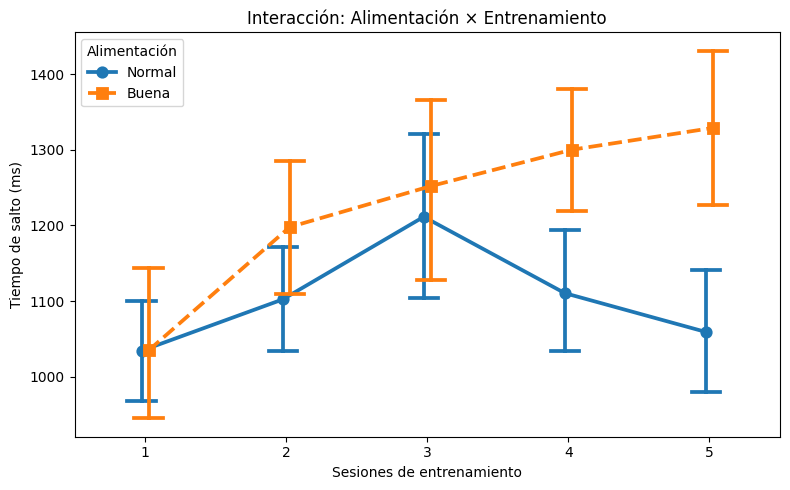

In [ ]:


import seaborn as sns
import matplotlib.pyplot as plt

def grafica_interaccion(df):
    plt.figure(figsize=(8,5))
    sns.pointplot(x="entrenamiento", 
                  y="tiempo_salto", 
                  hue="alimentacion",
                  data=df,
                  errorbar=("ci", 95),   # IC 95%
                  capsize=0.2,
                  dodge=True,
                  markers=["o", "s"],
                  linestyles=["-", "--"])
    
    plt.title("Interacción: Alimentación × Entrenamiento")
    plt.ylabel("Tiempo de salto (ms)")
    plt.xlabel("Sesiones de entrenamiento")
    plt.legend(title="Alimentación")
    plt.tight_layout()
    plt.show()

# Ejemplo de uso
grafica_interaccion(df)


In [ ]:

from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Comparaciones múltiples para el factor entrenamiento
tukey = pairwise_tukeyhsd(
    endog=df["tiempo_salto"],        # variable dependiente
    groups=df["entrenamiento"],      # factor a comparar
    alpha=0.05                       # nivel de significancia
)

print(tukey)


  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj    lower    upper   reject
-------------------------------------------------------
     1      2 114.2832 0.1624  -24.9206  253.487  False
     1      3 197.1332 0.0061   39.7955 354.4709   True
     1      4 191.0652 0.0007   61.1382 320.9922   True
     1      5 183.7215 0.0038   42.8112 324.6317   True
     2      3    82.85 0.5819  -72.1316 237.8316  False
     2      4   76.782 0.4588  -50.2816 203.8456  False
     2      5  69.4382 0.6395  -68.8362 207.7127  False
     3      4   -6.068    1.0 -152.7739 140.6378  False
     3      5 -13.4118 0.9993 -169.9279 143.1043  False
     4      5  -7.3437 0.9999 -136.2746 121.5871  False
-------------------------------------------------------


In [126]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Filtrar solo alimentación = Normal
df_normal = df[df["alimentacion"] == "Normal"]

# Comparaciones múltiples para entrenamiento (solo Normal)
tukey_normal = pairwise_tukeyhsd(
    endog=df_normal["tiempo_salto"],       # variable dependiente
    groups=df_normal["entrenamiento"],     # factor a comparar
    alpha=0.05
)

print(tukey_normal)


  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2  meandiff p-adj    lower    upper   reject
--------------------------------------------------------
     1      2   67.8482 0.7509  -89.4788 225.1753  False
     1      3  177.0596  0.057   -3.3423 357.4615  False
     1      4   76.1427 0.6523  -79.3442 231.6296  False
     1      5   24.8444 0.9941 -144.5936 194.2823  False
     2      3  109.2114  0.457  -72.7789 291.2017  False
     2      4    8.2945 0.9999 -149.0325 165.6216  False
     2      5  -43.0039  0.956  -214.132 128.1242  False
     3      4 -100.9169 0.5283 -281.3188   79.485  False
     3      5 -152.2153 0.1888 -344.7715  40.3409  False
     4      5  -51.2984 0.9164 -220.7363 118.1395  False
--------------------------------------------------------


In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Filtrar solo alimentación = Normal
df_normal = df[df["alimentacion"] == "B"]

# Comparaciones múltiples para entrenamiento (solo Normal)
tukey_normal = pairwise_tukeyhsd(
    endog=df_normal["tiempo_salto"],       # variable dependiente
    groups=df_normal["entrenamiento"],     # factor a comparar
    alpha=0.05
)

print(tukey_normal)


  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj    lower    upper   reject
-------------------------------------------------------
     1      2  162.974 0.2363  -54.5406 380.4886  False
     1      3 217.1307 0.1009  -25.0165 459.2779  False
     1      4  265.279 0.0027   68.6726 461.8854   True
     1      5 294.1067 0.0018    82.991 505.2224   True
     2      3  54.1567 0.9661 -176.8808 285.1942  False
     2      4  102.305 0.5296  -80.4438 285.0538  False
     2      5 131.1328 0.3583   -67.142 329.4075  False
     3      4  48.1483 0.9695 -163.3223 259.6189  False
     3      5   76.976 0.8764 -148.0474 301.9995  False
     4      5  28.8277 0.9909 -146.2562 203.9116  False
-------------------------------------------------------
